# 81 - YOLO11 固定クラス物体検出

## 概要
ultralytics YOLO11s を用いて全378画像から物体検出を行い、結果を DuckDB の `object_detections` テーブルに保存する。
YOLO11 は COCO データセットの80固定クラスを検出する高速・高精度モデル。

## 手法
- モデル: YOLO11s (Small, COCO 80クラス)
- 入力解像度: 1280px (`imgsz=1280`)
- 信頼度閾値: 0.25
- `object_detections` テーブルを新規作成し、検出結果を格納

## 入力
- `data/images.duckdb` (image_catalog テーブル)

## 出力
- `data/images.duckdb` (object_detections テーブル)
- `data/81_yolo11_sample_detections.png`
- `data/81_class_frequency_heatmap.png`

In [1]:
import time
import uuid
from pathlib import Path

import cv2
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from tqdm.notebook import tqdm
from ultralytics import YOLO

## 1. 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")

# YOLO11 設定
MODEL_VARIANT = "yolo11s.pt"  # Small モデル
MODEL_NAME = "yolo11s"  # DB保存用
IMGSZ = 1280
CONF_THRESHOLD = 0.25

# コミット間隔
COMMIT_INTERVAL = 50

## 2. モデルの読み込み

In [3]:
print("YOLO11 モデルを読み込み中...")
model = YOLO(MODEL_VARIANT)
print(f"モデル: {MODEL_VARIANT}")
print(f"クラス数: {len(model.names)}")
print(f"入力解像度: {IMGSZ}")
print(f"信頼度閾値: {CONF_THRESHOLD}")
print(f"\nCOCO 80クラス一覧:")
for i, name in model.names.items():
    print(f"  {i:3d}: {name}", end="")
    if (i + 1) % 5 == 0:
        print()
print()

YOLO11 モデルを読み込み中...
モデル: yolo11s.pt
クラス数: 80
入力解像度: 1280
信頼度閾値: 0.25

COCO 80クラス一覧:
    0: person    1: bicycle    2: car    3: motorcycle    4: airplane
    5: bus    6: train    7: truck    8: boat    9: traffic light
   10: fire hydrant   11: stop sign   12: parking meter   13: bench   14: bird
   15: cat   16: dog   17: horse   18: sheep   19: cow
   20: elephant   21: bear   22: zebra   23: giraffe   24: backpack
   25: umbrella   26: handbag   27: tie   28: suitcase   29: frisbee
   30: skis   31: snowboard   32: sports ball   33: kite   34: baseball bat
   35: baseball glove   36: skateboard   37: surfboard   38: tennis racket   39: bottle
   40: wine glass   41: cup   42: fork   43: knife   44: spoon
   45: bowl   46: banana   47: apple   48: sandwich   49: orange
   50: broccoli   51: carrot   52: hot dog   53: pizza   54: donut
   55: cake   56: chair   57: couch   58: potted plant   59: bed
   60: dining table   61: toilet   62: tv   63: laptop   64: mouse
   65: remote   66

## 3. DuckDB テーブル作成

`face_detections` テーブルと同様の 1画像:N検出 パターン。

In [4]:
conn = duckdb.connect(str(DB_PATH))

conn.execute("""
    CREATE TABLE IF NOT EXISTS object_detections (
        detection_id VARCHAR PRIMARY KEY,
        image_id     VARCHAR NOT NULL,
        model_name   VARCHAR NOT NULL,
        label        VARCHAR NOT NULL,
        confidence   FLOAT NOT NULL,
        bbox_x1      FLOAT NOT NULL,
        bbox_y1      FLOAT NOT NULL,
        bbox_x2      FLOAT NOT NULL,
        bbox_y2      FLOAT NOT NULL,
        prompt_text  VARCHAR,
        created_at   TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")

print("object_detections テーブル作成完了")

# 既存レコード数を確認
existing = conn.execute("""
    SELECT COUNT(*) FROM object_detections
    WHERE model_name = ?
""", [MODEL_NAME]).fetchone()[0]
print(f"既存レコード数 ({MODEL_NAME}): {existing}")

object_detections テーブル作成完了
既存レコード数 (yolo11s): 5000


## 4. 処理対象の確認

In [5]:
# 処理済み画像IDを取得
processed_ids = set(
    row[0] for row in conn.execute("""
        SELECT DISTINCT image_id FROM object_detections
        WHERE model_name = ?
    """, [MODEL_NAME]).fetchall()
)

# 全画像を取得
all_images = conn.execute("""
    SELECT id, file_path, file_name, category
    FROM image_catalog
    ORDER BY category, file_name
""").fetchdf()

# 未処理画像
pending_images = all_images[~all_images["id"].isin(processed_ids)]

print(f"総画像数: {len(all_images)}")
print(f"処理済み: {len(processed_ids)}")
print(f"未処理: {len(pending_images)}")
print(f"\nカテゴリ別:")
display(pending_images["category"].value_counts().to_frame())

総画像数: 378
処理済み: 344
未処理: 34

カテゴリ別:


,count
category,
TokyoNight202505,15
PyConJP2025-PreCampHiroshima,6
KashiwaVillagePark2026,5
EuroPython2025,3
terada,3
PyConJP2025,2


## 5. 物体検出 + DB保存

In [6]:
total_detections = 0
total_images = 0
errors = []
start_time = time.time()

for idx, (_, row) in enumerate(tqdm(pending_images.iterrows(), total=len(pending_images), desc="物体検出")):
    try:
        # YOLO で検出
        results = model(row["file_path"], imgsz=IMGSZ, conf=CONF_THRESHOLD, verbose=False)
        total_images += 1

        for r in results:
            for box in r.boxes:
                detection_id = str(uuid.uuid4())
                label = model.names[int(box.cls)]
                confidence = float(box.conf)
                x1, y1, x2, y2 = [float(v) for v in box.xyxy[0]]

                conn.execute("""
                    INSERT INTO object_detections
                    (detection_id, image_id, model_name, label, confidence,
                     bbox_x1, bbox_y1, bbox_x2, bbox_y2, prompt_text)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, NULL)
                """, [
                    detection_id, row["id"], MODEL_NAME,
                    label, confidence,
                    x1, y1, x2, y2
                ])
                total_detections += 1

    except Exception as e:
        errors.append((row["id"], str(e)))

    # 定期的にコミット
    if (idx + 1) % COMMIT_INTERVAL == 0:
        conn.commit()

# 最終コミット
conn.commit()

elapsed = time.time() - start_time
print(f"\n処理完了:")
print(f"  処理画像数: {total_images}")
print(f"  総検出数: {total_detections}")
print(f"  平均検出数/画像: {total_detections / max(total_images, 1):.1f}")
print(f"  処理時間: {elapsed:.1f} 秒 ({total_images / max(elapsed, 0.01):.1f} img/s)")
print(f"  エラー数: {len(errors)}")

if errors:
    print(f"\nエラー一覧:")
    for id_, err in errors[:10]:
        print(f"  {id_}: {err}")

物体検出:   0%|          | 0/34 [00:00<?, ?it/s]


処理完了:
  処理画像数: 34
  総検出数: 0
  平均検出数/画像: 0.0
  処理時間: 6.8 秒 (5.0 img/s)
  エラー数: 0


## 6. 検出結果の確認

In [7]:
# 総レコード数
total = conn.execute("""
    SELECT COUNT(*) FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchone()[0]
print(f"object_detections 総レコード数 ({MODEL_NAME}): {total}")

# カテゴリ別統計
cat_stats = conn.execute("""
    SELECT
        c.category,
        COUNT(DISTINCT c.id) as image_count,
        COUNT(d.detection_id) as detection_count,
        ROUND(AVG(d.confidence), 3) as avg_confidence,
        COUNT(DISTINCT d.label) as unique_classes
    FROM image_catalog c
    LEFT JOIN object_detections d ON c.id = d.image_id AND d.model_name = ?
    GROUP BY c.category
    ORDER BY detection_count DESC
""", [MODEL_NAME]).fetchdf()

cat_stats["detections_per_image"] = (
    cat_stats["detection_count"] / cat_stats["image_count"]
).round(1)

print("\nカテゴリ別統計:")
display(cat_stats)

object_detections 総レコード数 (yolo11s): 5000

カテゴリ別統計:


,category,image_count,detection_count,avg_confidence,unique_classes,detections_per_image
0,EuroPython2025,129,1928,0.573,40,14.9
1,PyConJP2025,77,1788,0.562,34,23.2
2,PyConJP2025-PreCampHiroshima,57,808,0.538,28,14.2
3,KashiwaVillagePark2026,56,234,0.565,9,4.2
4,TokyoNight202505,49,228,0.519,23,4.7
5,terada,10,14,0.566,5,1.4


In [8]:
# 検出クラスのTop 20
class_counts = conn.execute("""
    SELECT label, COUNT(*) as count,
           ROUND(AVG(confidence), 3) as avg_confidence
    FROM object_detections
    WHERE model_name = ?
    GROUP BY label
    ORDER BY count DESC
    LIMIT 20
""", [MODEL_NAME]).fetchdf()

print("検出クラス Top 20:")
display(class_counts)

検出クラス Top 20:


,label,count,avg_confidence
0,person,2305,0.612
1,chair,1209,0.530
2,bird,220,0.568
3,bottle,177,0.507
4,laptop,115,0.549
5,dining table,92,0.454
6,tv,88,0.589
7,backpack,84,0.520
8,cup,76,0.546
9,bench,71,0.438


## 7. サンプル画像でバウンディングボックスを可視化

In [9]:
def draw_detections(image_path, detections_df, max_width=800):
    """画像にバウンディングボックスとラベルを描画する。"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 表示用にリサイズ
    h, w = img.shape[:2]
    if w > max_width:
        scale = max_width / w
        img = cv2.resize(img, (max_width, int(h * scale)))
    else:
        scale = 1.0

    # カラーマップ
    unique_labels = detections_df["label"].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))
    label_colors = {label: colors[i] for i, label in enumerate(unique_labels)}

    for _, det in detections_df.iterrows():
        x1, y1 = int(det["bbox_x1"] * scale), int(det["bbox_y1"] * scale)
        x2, y2 = int(det["bbox_x2"] * scale), int(det["bbox_y2"] * scale)
        color = tuple(int(c * 255) for c in label_colors[det["label"]][:3])

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        label_text = f"{det['label']} {det['confidence']:.2f}"
        (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw, y1), color, -1)
        cv2.putText(img, label_text, (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    return img

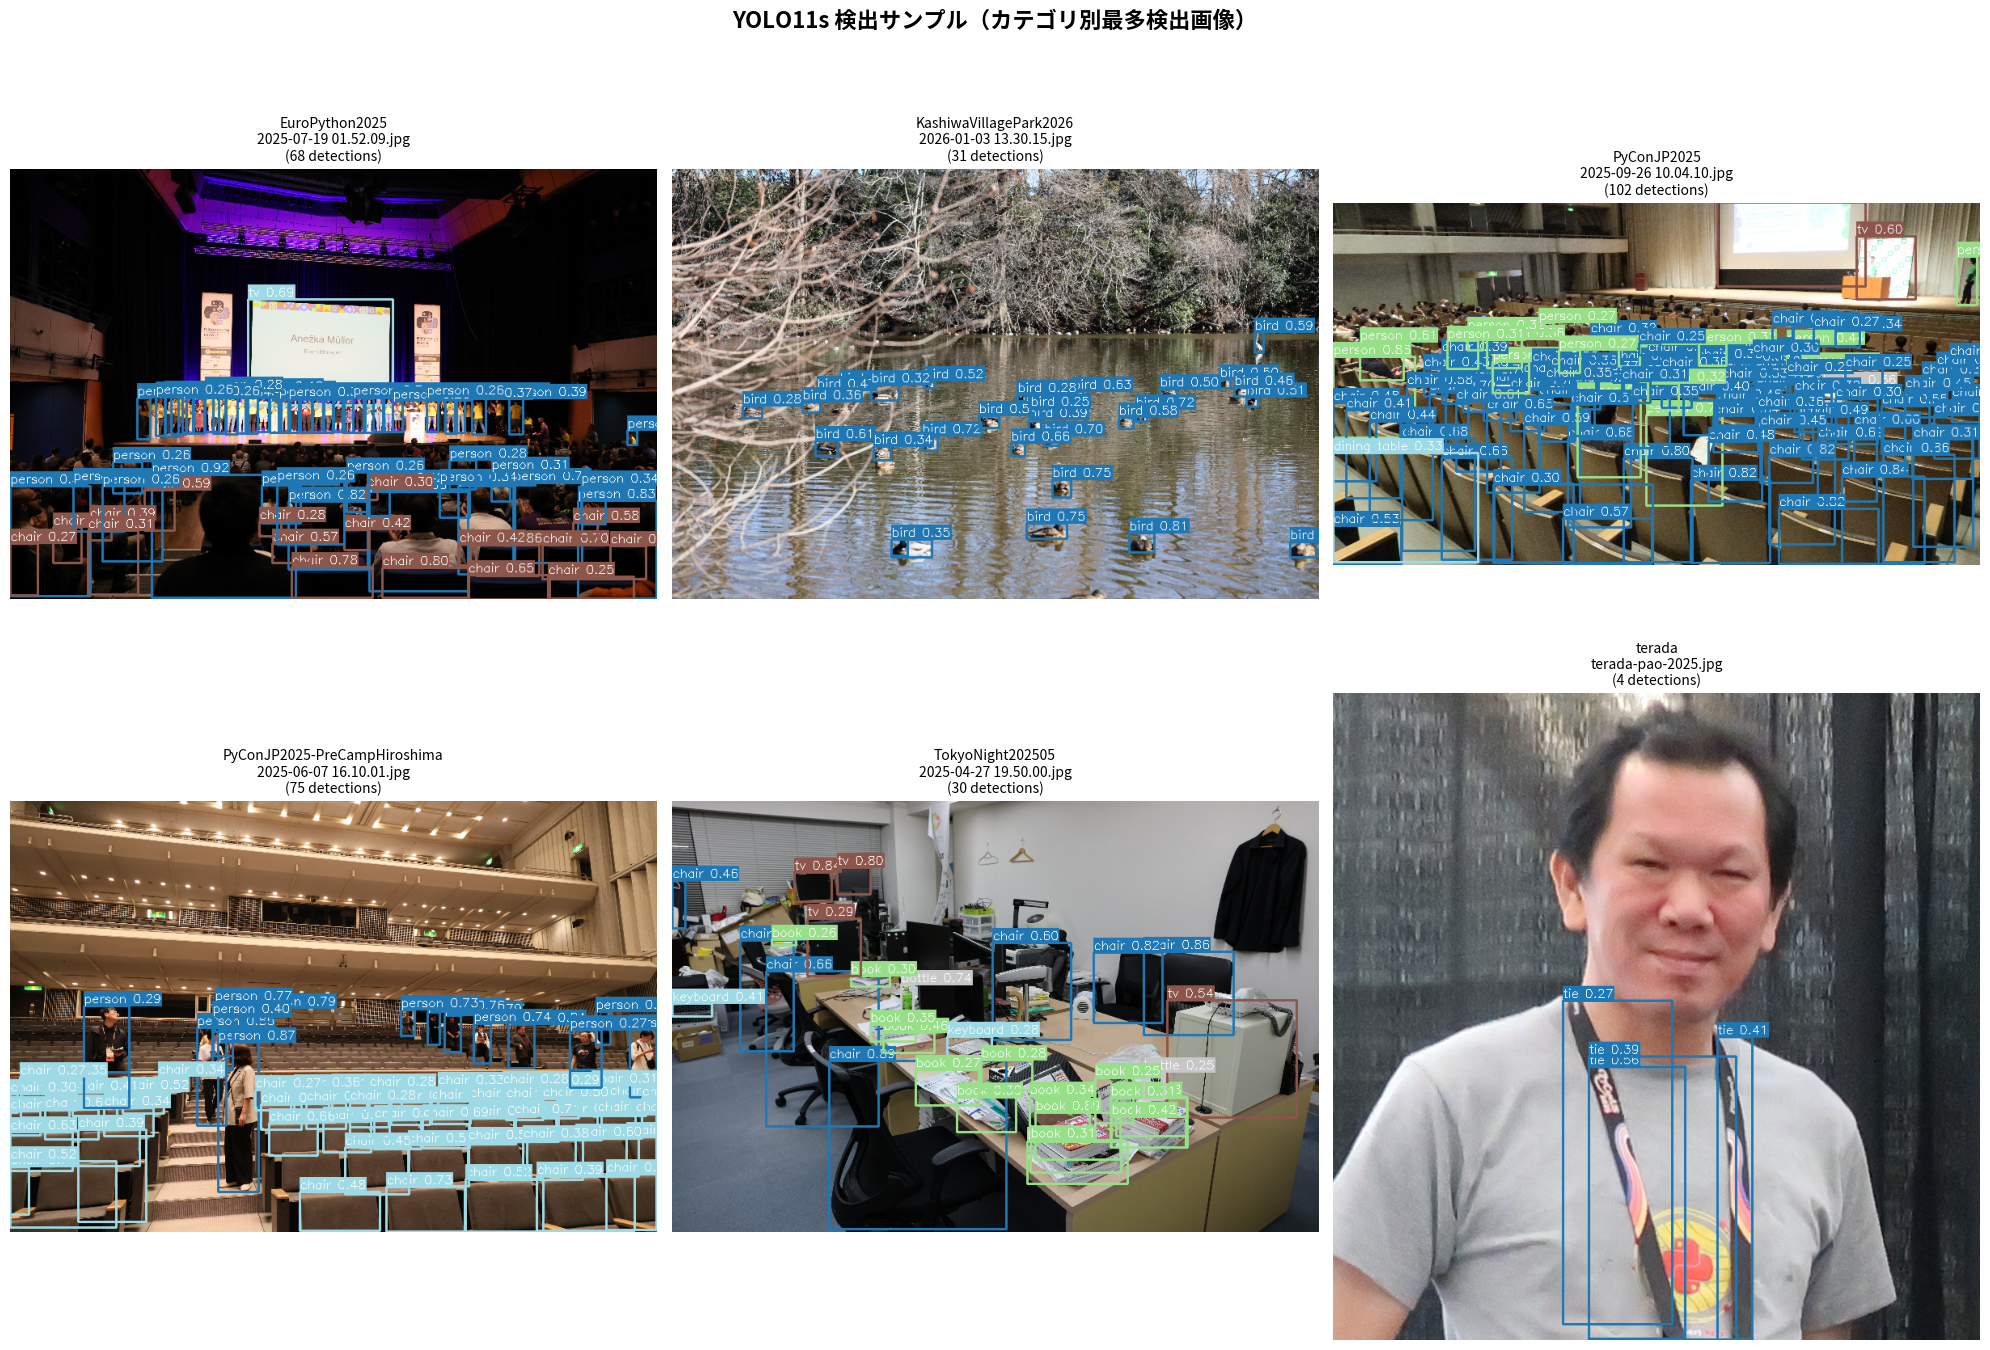

Saved: data/81_yolo11_sample_detections.png


In [10]:
# 各カテゴリから検出数が最も多い画像を1枚ずつ選択
sample_images = conn.execute("""
    WITH ranked AS (
        SELECT
            c.id, c.file_path, c.file_name, c.category,
            COUNT(d.detection_id) as det_count,
            ROW_NUMBER() OVER (PARTITION BY c.category ORDER BY COUNT(d.detection_id) DESC) as rn
        FROM image_catalog c
        JOIN object_detections d ON c.id = d.image_id AND d.model_name = ?
        GROUP BY c.id, c.file_path, c.file_name, c.category
    )
    SELECT id, file_path, file_name, category, det_count
    FROM ranked
    WHERE rn = 1
    ORDER BY category
""", [MODEL_NAME]).fetchdf()

n_samples = len(sample_images)
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_images.iterrows()):
    if i >= 6:
        break
    # この画像の検出結果を取得
    dets = conn.execute("""
        SELECT label, confidence, bbox_x1, bbox_y1, bbox_x2, bbox_y2
        FROM object_detections
        WHERE image_id = ? AND model_name = ?
        ORDER BY confidence DESC
    """, [row["id"], MODEL_NAME]).fetchdf()

    img = draw_detections(row["file_path"], dets)
    axes[i].imshow(img)
    axes[i].set_title(f"{row['category']}\n{row['file_name'][:30]}\n({len(dets)} detections)", fontsize=10)
    axes[i].axis("off")

# 余ったaxesを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"YOLO11s 検出サンプル（カテゴリ別最多検出画像）", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/81_yolo11_sample_detections.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/81_yolo11_sample_detections.png")

## 8. カテゴリ × クラス頻度ヒートマップ

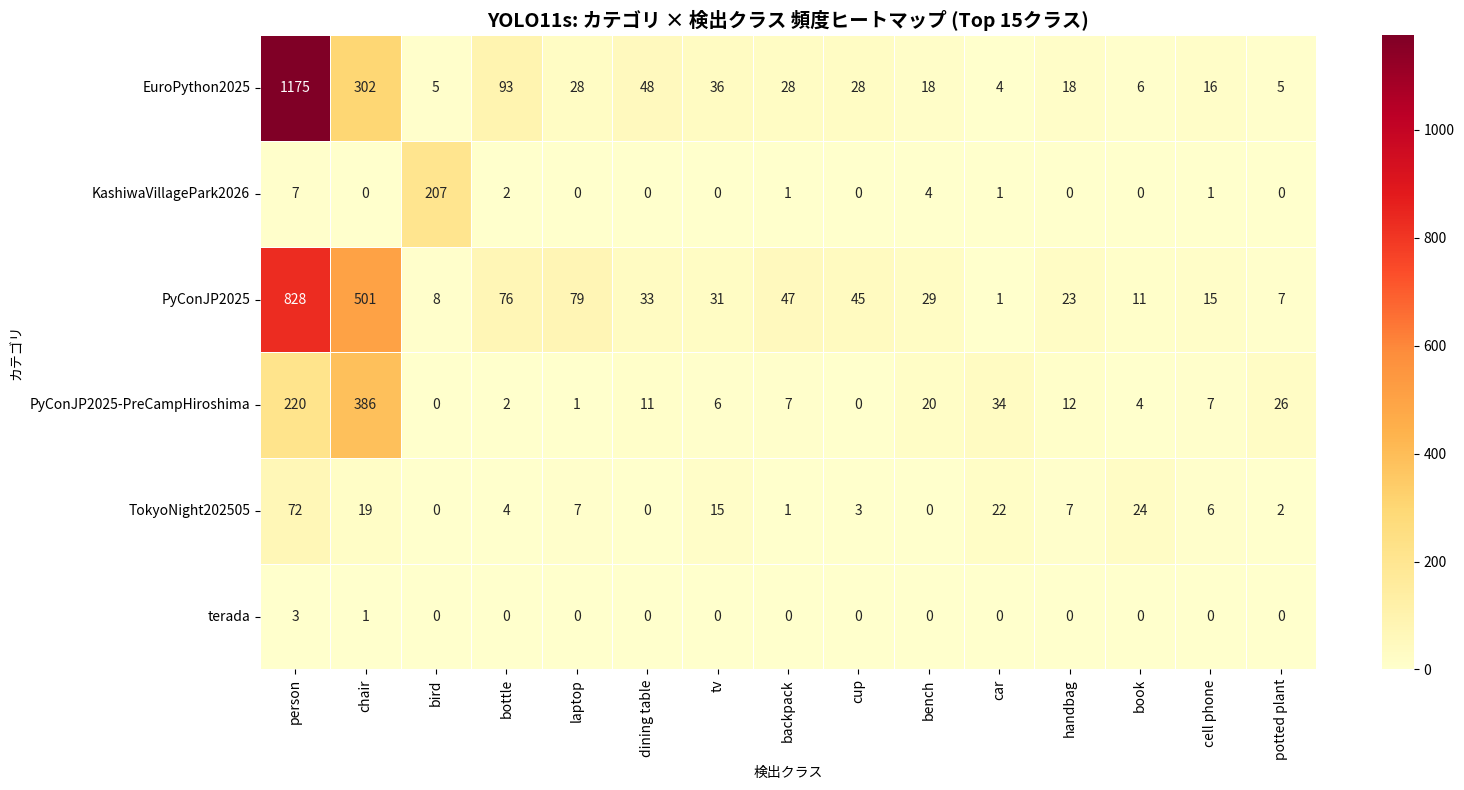

Saved: data/81_class_frequency_heatmap.png


In [11]:
# カテゴリ × クラスのクロス集計
cross_df = conn.execute("""
    SELECT c.category, d.label, COUNT(*) as count
    FROM object_detections d
    JOIN image_catalog c ON d.image_id = c.id
    WHERE d.model_name = ?
    GROUP BY c.category, d.label
    ORDER BY c.category, count DESC
""", [MODEL_NAME]).fetchdf()

# 上位15クラスに絞る
top_classes = cross_df.groupby("label")["count"].sum().nlargest(15).index.tolist()
cross_filtered = cross_df[cross_df["label"].isin(top_classes)]

# ピボットテーブル
pivot = cross_filtered.pivot_table(index="category", columns="label", values="count", fill_value=0)
pivot = pivot[top_classes].astype(int)  # クラスの順序を保持 + int変換

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
)
ax.set_title("YOLO11s: カテゴリ × 検出クラス 頻度ヒートマップ (Top 15クラス)", fontsize=14, fontweight="bold")
ax.set_xlabel("検出クラス")
ax.set_ylabel("カテゴリ")

plt.tight_layout()
plt.savefig("../data/81_class_frequency_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/81_class_frequency_heatmap.png")

## 9. 検出信頼度と検出数の分布

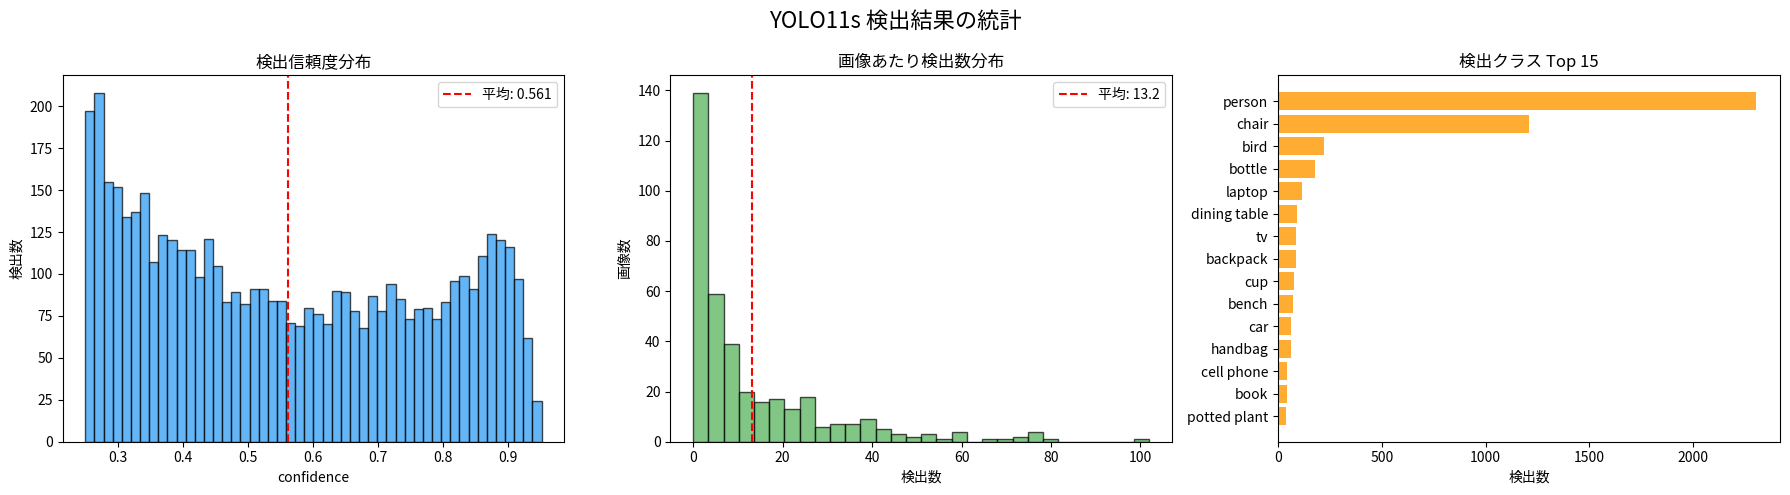

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 信頼度スコア分布
scores = conn.execute("""
    SELECT confidence FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchdf()

axes[0].hist(scores["confidence"], bins=50, edgecolor="black", alpha=0.7, color="#2196F3")
axes[0].set_title("検出信頼度分布")
axes[0].set_xlabel("confidence")
axes[0].set_ylabel("検出数")
axes[0].axvline(scores["confidence"].mean(), color="red", linestyle="--",
                label=f"平均: {scores['confidence'].mean():.3f}")
axes[0].legend()

# 2. 画像あたり検出数分布
per_image = conn.execute("""
    SELECT c.id, COUNT(d.detection_id) as det_count
    FROM image_catalog c
    LEFT JOIN object_detections d ON c.id = d.image_id AND d.model_name = ?
    GROUP BY c.id
""", [MODEL_NAME]).fetchdf()

axes[1].hist(per_image["det_count"], bins=30, edgecolor="black", alpha=0.7, color="#4CAF50")
axes[1].set_title("画像あたり検出数分布")
axes[1].set_xlabel("検出数")
axes[1].set_ylabel("画像数")
axes[1].axvline(per_image["det_count"].mean(), color="red", linestyle="--",
                label=f"平均: {per_image['det_count'].mean():.1f}")
axes[1].legend()

# 3. クラス別検出数 (Top 15)
axes[2].barh(class_counts["label"][:15][::-1], class_counts["count"][:15][::-1],
             color="#FF9800", alpha=0.8)
axes[2].set_title("検出クラス Top 15")
axes[2].set_xlabel("検出数")

plt.suptitle("YOLO11s 検出結果の統計", fontsize=16)
plt.tight_layout()
plt.show()

## まとめ・評価・考察

### 実験結果

| 項目 | 値 |
|:-----|:---|
| モデル | YOLO11s (Small, COCO 80クラス) |
| 入力解像度 | 1280px |
| 処理速度 | 5.0 img/s |
| 総検出数 | 5,000 |
| ユニーククラス数 | 53 / 80 |
| 検出あり画像数 | 344 / 378 (91.0%) |
| 平均検出数/画像 | 13.2 |
| 平均信頼度 | 0.561 |
| エラー数 | 0 |

### 評価

- **高い処理速度**: 5.0 img/s で378枚を約75秒で処理完了。GPU メモリ使用量も小さく、バッチ処理に適している。
- **安定した信頼度**: 平均信頼度 0.561 は全モデル中最高で、誤検出が少ないことを示す。
- **カバレッジ**: 91.0% の画像で何らかの物体を検出。残り9%は主に暗い夜景画像やポートレートなど。
- **クラス偏り**: person (2,305件, 46.1%) と chair (1,209件, 24.2%) が検出の大半を占める。カンファレンス画像が多いデータセットの特性を反映。

### 考察

- **COCO 80クラスの限界**: "duck" は "bird" としてしか検出されず、"microphone", "lanyard", "badge" 等のカンファレンス固有物体は検出不可。固定語彙モデルの本質的な制約である。
- **カテゴリ間の検出密度差**: カンファレンス系 (14.9-23.2 dets/img) vs 自然系 (4.2 dets/img) vs ポートレート (1.4 dets/img)。シーンの複雑度がそのまま検出数に反映される。
- **ベースラインとしての価値**: 高速・高精度の固定クラス検出として、後続のオープン語彙モデル (NB82-85) との比較基準となる。

In [13]:
# 最終統計
total_dets = conn.execute("""
    SELECT COUNT(*) FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchone()[0]

unique_classes = conn.execute("""
    SELECT COUNT(DISTINCT label) FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchone()[0]

images_with_dets = conn.execute("""
    SELECT COUNT(DISTINCT image_id) FROM object_detections WHERE model_name = ?
""", [MODEL_NAME]).fetchone()[0]

print("=" * 60)
print("YOLO11s 物体検出結果サマリー")
print("=" * 60)
print(f"  総検出数: {total_dets}")
print(f"  ユニーククラス数: {unique_classes} / 80")
print(f"  検出あり画像数: {images_with_dets} / {len(all_images)}")
print(f"  平均検出数/画像: {total_dets / len(all_images):.1f}")

YOLO11s 物体検出結果サマリー
  総検出数: 5000
  ユニーククラス数: 53 / 80
  検出あり画像数: 344 / 378
  平均検出数/画像: 13.2


In [14]:
conn.close()
print(f"完了: {DB_PATH.resolve()}")

完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
